# Vehicle Classification using CNN 2025-2026

In [1]:
# Standart Kütüphaneler
import os
import math
import warnings
warnings.filterwarnings("ignore")

# Veri İşleme
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Görüntü İşleme
import cv2
from PIL import Image

# Makine Öğrenmesi (sklearn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# TensorFlow / Keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    Flatten,
    Input,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, EfficientNetB0
from tensorflow.keras.utils import to_categorical

2026-04-23 07:54:20.556573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776930860.810695      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776930860.882557      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776930861.494160      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776930861.494227      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776930861.494231      55 computation_placer.cc:177] computation placer alr

## Loading and Organizing Data

In [7]:
# Paths
BASE_PATH = '/kaggle/input/competitions/vehicle-classification-using-cnn-2025-2026'
DATASET_PATH = os.path.join(BASE_PATH, 'Dataset')

# Train Test csv
train_csv = pd.read_csv(os.path.join(BASE_PATH, 'train.csv'))
test_csv  = pd.read_csv(os.path.join(BASE_PATH, 'test.csv'))

In [10]:
train_img_list   = [os.path.join(BASE_PATH, p) for p in train_csv['image']]
train_label_list = list(train_csv['label'])

test_img_list = [os.path.join(BASE_PATH, p) for p in test_csv['image']]

In [11]:
train_df = pd.DataFrame({'img': train_img_list, 'label': train_label_list})
test_df  = pd.DataFrame({'img': test_img_list})

In [12]:
# Label encoding — sınıfları alfabetik sıralayacagız
labels = {label: idx for idx, label in enumerate(sorted(train_df['label'].unique()))}

train_df['label_encoded'] = train_df['label'].map(labels)

In [16]:
labels

{'baobao': 0,
 'bus': 1,
 'car': 2,
 'motorcycle': 3,
 'topdown': 4,
 'tricycle': 5,
 'van': 6}

In [13]:
train_df.sample(10)

,img,label,label_encoded
959,/kaggle/input/competitions/vehicle-classificat...,motorcycle,3
1050,/kaggle/input/competitions/vehicle-classificat...,motorcycle,3
753,/kaggle/input/competitions/vehicle-classificat...,car,2
1453,/kaggle/input/competitions/vehicle-classificat...,tricycle,5
378,/kaggle/input/competitions/vehicle-classificat...,bus,1
1174,/kaggle/input/competitions/vehicle-classificat...,topdown,4
1264,/kaggle/input/competitions/vehicle-classificat...,topdown,4
610,/kaggle/input/competitions/vehicle-classificat...,car,2
676,/kaggle/input/competitions/vehicle-classificat...,car,2
288,/kaggle/input/competitions/vehicle-classificat...,bus,1


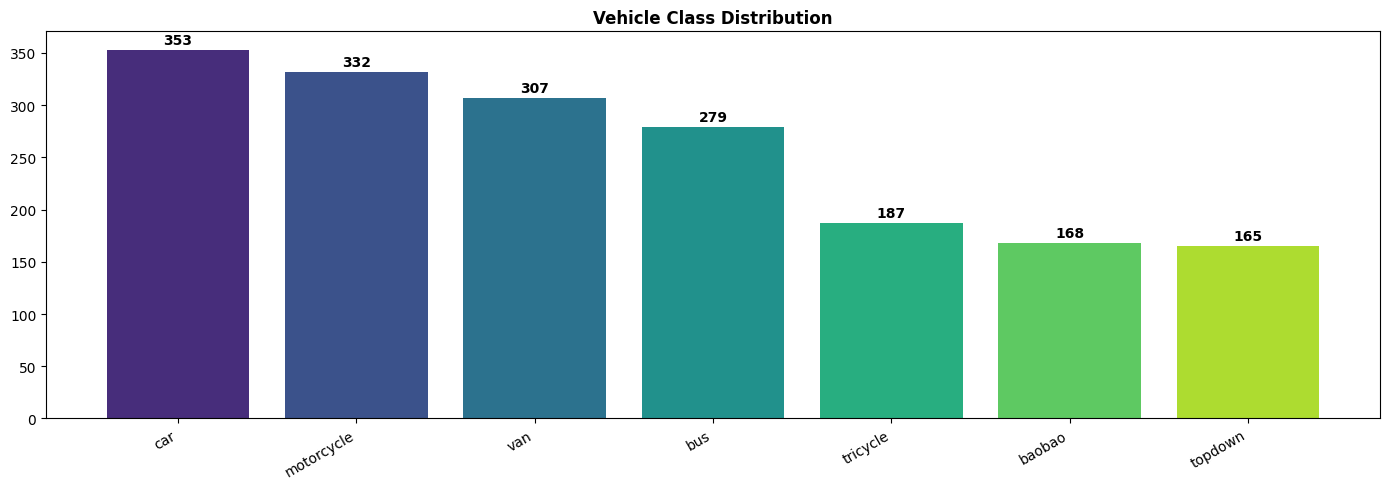

In [14]:
#Vehicle Class Distribution
plt.figure(figsize=(14, 5))
counts = train_csv['label'].value_counts()
colors = sns.color_palette("viridis", len(counts))
bars = plt.bar(counts.index, counts.values, color=colors)
plt.title("Vehicle Class Distribution", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.bar_label(bars, fontweight="bold", padding=2)
plt.tight_layout()
plt.show()

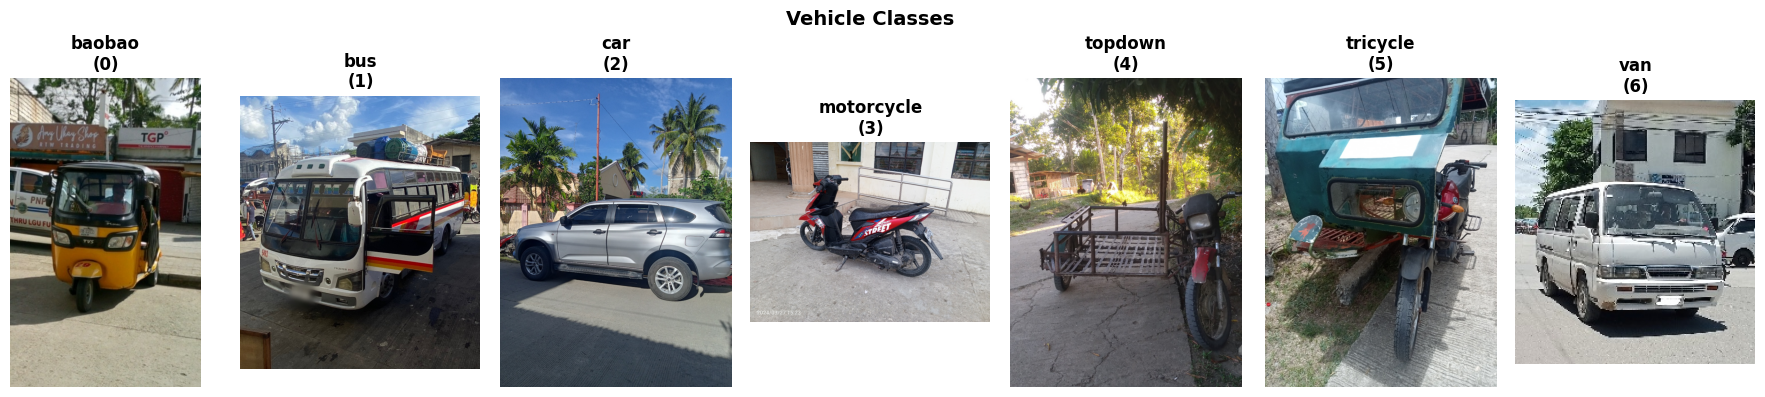

In [18]:
# Her sınıftan örnek görsel
plt.figure(figsize=(18, 4))

for i, (label, idx) in enumerate(labels.items(), 1):
    plt.subplot(1, 7, i)
    path = train_df[train_df['label'] == label]['img'].iloc[0]
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"{label}\n({idx})", fontweight='bold')
    plt.axis('off')

plt.suptitle("Vehicle Classes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Normalization

In [19]:
# Görüntü Yükleme ve Normalizasyon
def load_image(img_path, img_size=(128, 128)):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    return img / 255.0

In [20]:
def load_dataset(df, img_size=(128, 128), has_label=True):
    images = []
    labels = []

    for row in df.itertuples():
        img = cv2.imread(row.img)
        if img is None:
            raise ValueError(f"Görsel okunamadı: {row.img}")
        img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), img_size) / 255.0
        images.append(img)

        if has_label:
            labels.append(row.label_encoded)

    images = np.array(images)

    if has_label:
        return images, np.array(labels)
    else:
        return images

In [22]:
x_train, y_train = load_dataset(train_df, has_label=True)
print(f"✅ Train verisi : {x_train.shape}")    


x_test = load_dataset(test_df, has_label=False)
print(f"✅ Test verisi  : {x_test.shape}")

✅ Train verisi : (1791, 128, 128, 3)
✅ Test verisi  : (448, 128, 128, 3)


## Train / Validation Split

In [23]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print(f"Train : {x_train.shape} | Val : {x_val.shape}")

Train : (1432, 128, 128, 3) | Val : (359, 128, 128, 3)


## CNN Modeling

In [24]:
model = Sequential([
    Input(shape=(128, 128, 3)),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(7, activation='softmax')  # 7 classes
])

2026-04-23 08:21:51.389736: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [25]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,587,719 (17.50 MB)

 Trainable params: 4,586,247 (17.50 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [27]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [28]:
# Training
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.2874 - loss: 3.2398 - val_accuracy: 0.0919 - val_loss: 7.2158 - learning_rate: 0.0010
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4925 - loss: 2.3767 - val_accuracy: 0.0919 - val_loss: 5.7095 - learning_rate: 0.0010
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5594 - loss: 2.2275 - val_accuracy: 0.0919 - val_loss: 5.1057 - learning_rate: 0.0010
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.6492 - loss: 1.8984 - val_accuracy: 0.0919 - val_loss: 7.0284 - learning_rate: 0.0010
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.6858 - loss: 1.8272 - val_accuracy: 0.0919 - val_loss: 7.0640 - learning_rate: 0.0010
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7471 - loss: 1.6399 - val_accuracy: 0.0975 - val_loss: 4.6420 - learning_rate: 0.0010
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7553 - loss: 1.6037 - val_accuracy: 

## Saving the Model

In [29]:
model.save('vehicle_cnn.h5')

In [30]:
model.save('vehicle_cnn.h5')

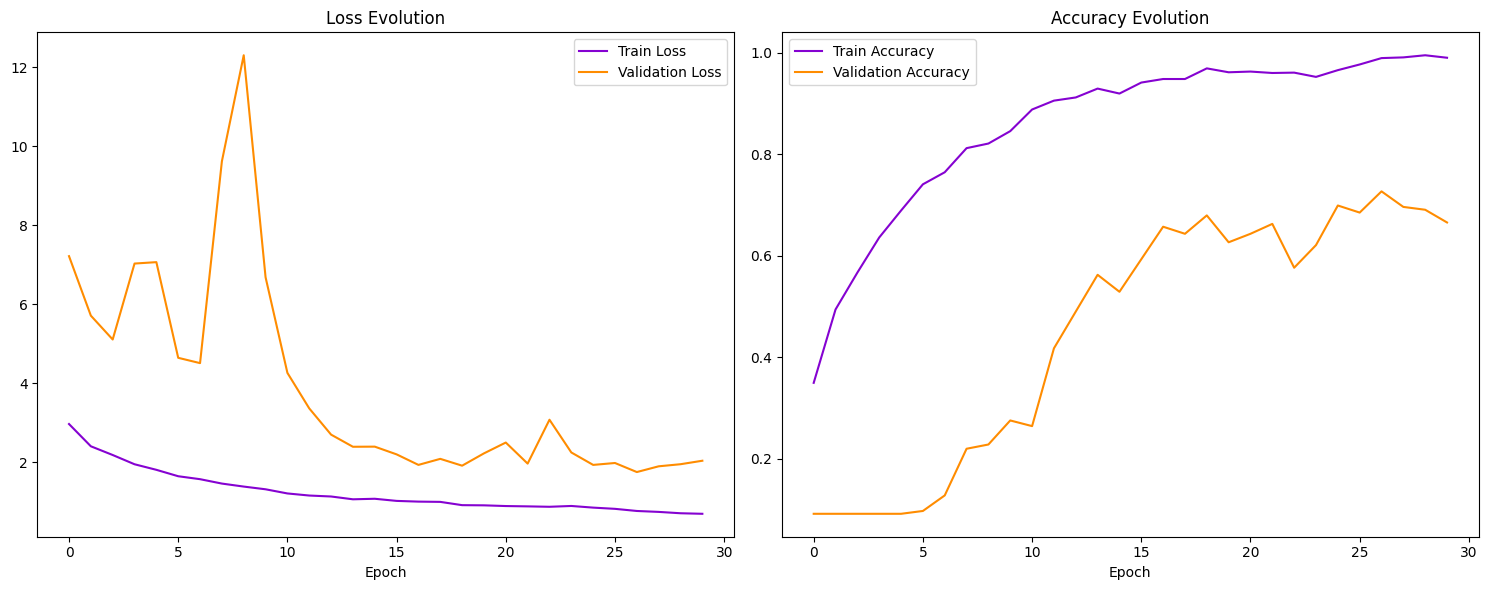

In [31]:
# Loss & Accuracy 
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss',      color='#8502d1')
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy',      color='#8502d1')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step


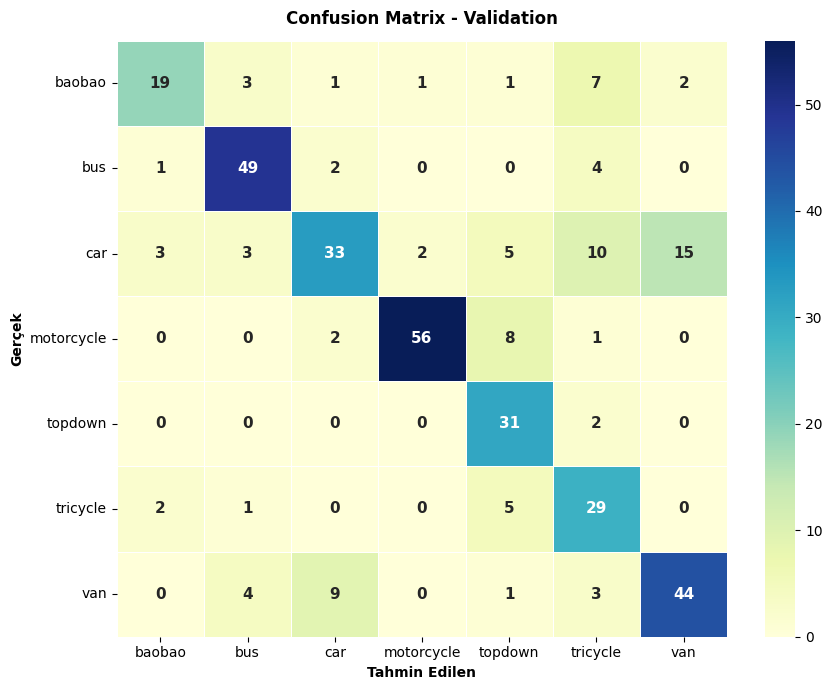

In [34]:
# Confusion Matrix - Validation
y_pred = np.argmax(model.predict(x_val), axis=1)
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    cmap="YlGnBu",
    annot=True,
    fmt="d",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=list(labels.keys()),
    yticklabels=list(labels.keys()),
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title("Confusion Matrix - Validation", pad=12, weight="bold")
plt.xlabel("Tahmin Edilen", weight="bold")
plt.ylabel("Gerçek", weight="bold")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Predict on the Test

In [35]:
tahmin = model.predict(x_test)

tahmin_classes = np.argmax(tahmin, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step


In [37]:
class_names = {
    0: 'baobao',
    1: 'bus',
    2: 'car',
    3: 'motorcycle',
    4: 'topdown',
    5: 'tricycle',
    6: 'van'
}

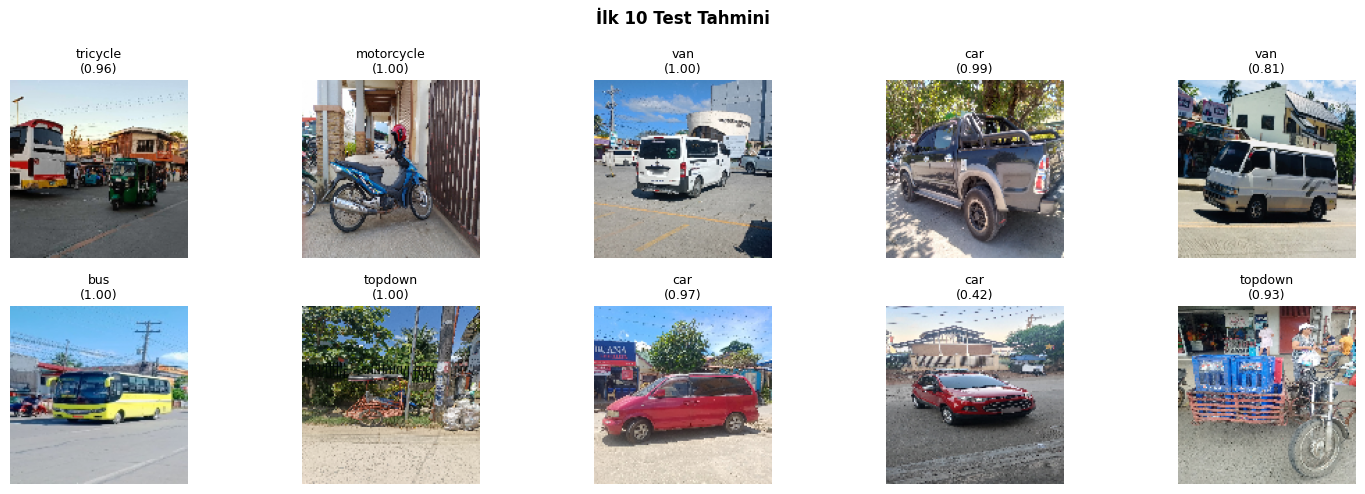

In [38]:
# İlk 10 test görseli
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])

    pred_class = tahmin_classes[i]
    confidence = tahmin[i][pred_class]

    plt.title(f"{class_names[pred_class]}\n({confidence:.2f})", fontsize=9)
    plt.axis('off')

plt.suptitle('İlk 10 Test Tahmini', fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
tahmin_labels = [class_names[i] for i in tahmin_classes]

In [41]:
submission = pd.DataFrame({
    'id':    test_csv['id'],
    'label': tahmin_labels
})

In [42]:
submission = submission.sort_values('id').reset_index(drop=True)

In [43]:
submission.head()

,id,label
0,0,tricycle
1,1,motorcycle
2,2,van
3,3,car
4,4,van


In [44]:
submission.to_csv('submission.csv', index=False)